<a href="https://colab.research.google.com/github/solitude-ui/House-price-prediction/blob/main/TrialMlprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-Data prepaeration and analysis

## **Data Loading**

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

## **EDA**

In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [ ]:
df.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


## **Data Preprocessing**

### Handling NUll/Missing values

In [ ]:
df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


### Encoding the data

In [ ]:
# using label Encoder

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
lb=LabelEncoder()

In [ ]:
columns_to_standard=["Attrition","BusinessTravel","Gender","MaritalStatus","Over18","OverTime"]
for col in columns_to_standard:
  df[col]=lb.fit_transform(df[col])
df.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


In [ ]:
# #using onehot encoder
# from sklearn.preprocessing import OneHotEncoder

In [ ]:
# oh=OneHotEncoder(sparse_output=False)

In [ ]:
colums_to_onehotencode=["Department","EducationField","JobRole"]
for col in colums_to_onehotencode:
  df=pd.get_dummies(df,columns=[col],dtype=int)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,...,EducationField_Technical Degree,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative
0,41,1,2,1102,1,2,1,1,2,0,...,0,0,0,0,0,0,0,0,1,0
1,49,0,1,279,8,1,1,2,3,1,...,0,0,0,0,0,0,0,1,0,0
2,37,1,2,1373,2,2,1,4,4,1,...,0,0,0,1,0,0,0,0,0,0
3,33,0,1,1392,3,4,1,5,4,0,...,0,0,0,0,0,0,0,1,0,0
4,27,0,2,591,2,1,1,7,1,1,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
df.dtypes

,0
Age,int64
Attrition,int64
BusinessTravel,int64
DailyRate,int64
DistanceFromHome,int64
Education,int64
EmployeeCount,int64
EmployeeNumber,int64
EnvironmentSatisfaction,int64
Gender,int64


### Feature Engineering/Extraction

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
corr_result=df.corr()["Attrition"]# for target data only
plt.figure(figsize=(10,12))
sns.heatmap(data=corr_result,cmap="coolwarm",annot=True,linewidths=0.5,vmin=-1,vmax=1,center=0)
plt.show()

NameError: name 'df' is not defined

In [ ]:
#my absolute value is 0.15
#my target is Attrition
corr_columns=["Attrition","JobLevel","OverTime","TotalWorkingYears"]
df.drop(columns=df.columns.difference(corr_columns),inplace=True)

In [ ]:
df.head()

,Attrition,JobLevel,OverTime,TotalWorkingYears
0,1,2,1,8
1,0,2,0,10
2,1,1,1,7
3,0,1,1,8
4,0,1,0,6


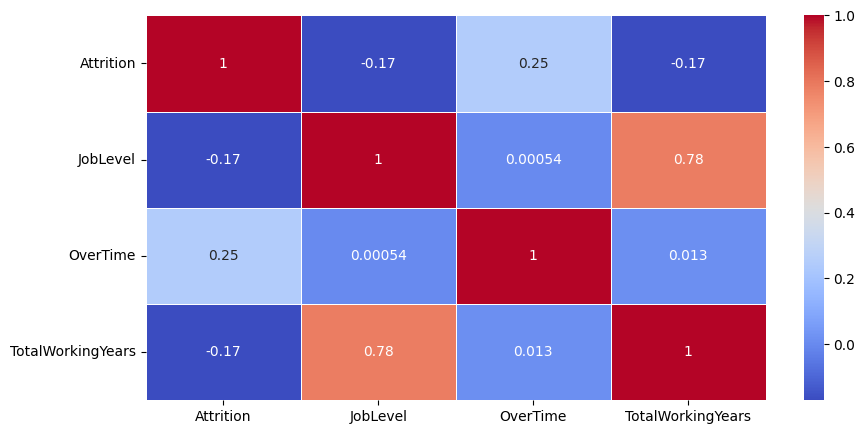

In [ ]:
corr_result=df.corr()
plt.figure(figsize=(10,5))
sns.heatmap(data=corr_result,cmap="coolwarm",annot=True,linewidths=0.5)
plt.show()

Handling Outliers

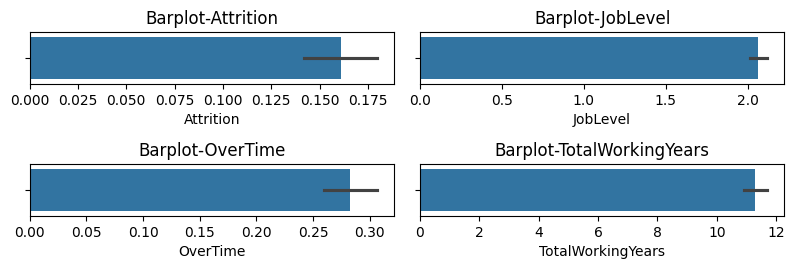

In [ ]:
plt.figure(figsize=(8,5))
columns=df.columns

for i,col in enumerate(columns):
  plt.subplot(len(columns),2,i+1)
  sns.barplot(x=df[col])
  plt.title(f"Barplot-{col}")
plt.tight_layout()
plt.show()

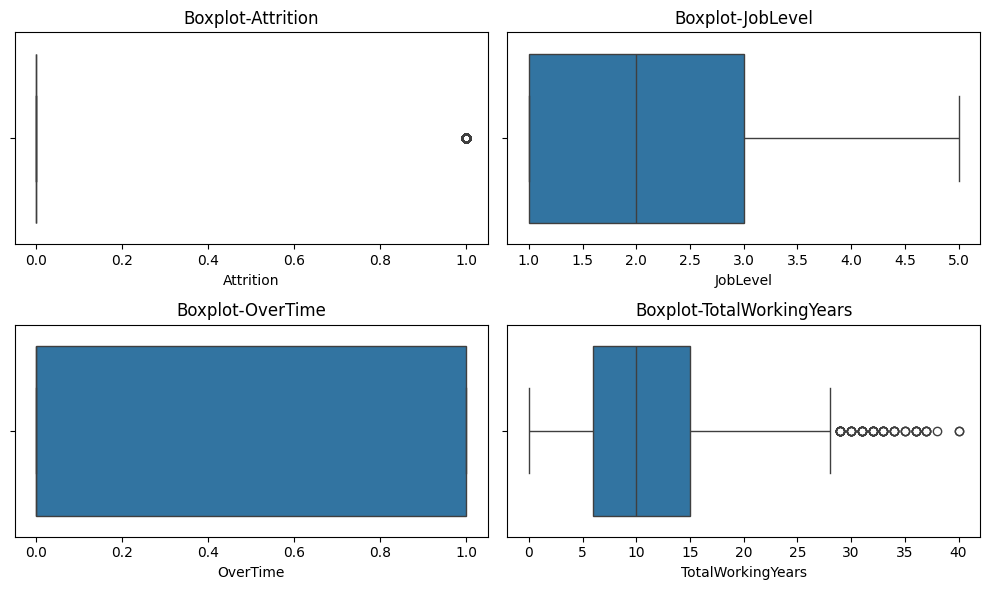

In [ ]:
import math
n_cols = 2
#Calculates the number of grid rows needed.
n_rows = math.ceil(len(df.columns) / n_cols)
plt.figure(figsize=(10, 3 * n_rows))

for i, col in enumerate(df.columns):
    plt.subplot(n_rows, n_cols, i + 1)
    # Boxplots explicitly draw outlier points beyond 1.5 * IQR
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot-{col}")

plt.tight_layout()
plt.show()

In [ ]:

#fixing the outliers

cols_with_outliers=["TotalWorkingYears"]

def fixCols():
  for col in cols_with_outliers:
    Q1=df[col].quantile(.25)
    Q3=df[col].quantile(.75)

    IQR=Q3-Q1

    upper_bound=Q3+1.5*IQR
    lower_bound=Q1-1.5*IQR

    initial_outlier=df[(df[col]<lower_bound)|(df[col]>upper_bound)]

    print(f"Outliers in {col} before treatment:",initial_outlier[col].count())
    print("Treating Outliers...")
    df[col]=df[col].clip(upper=upper_bound,lower=lower_bound)
    final_outlier=df[(df[col]<lower_bound)|(df[col]>upper_bound)]
    print(f"Outliers in {col} after treatment:",final_outlier[col].count())

fixCols()




Outliers in TotalWorkingYears before treatment: 63
Treating Outliers...
Outliers in TotalWorkingYears after treatment: 0


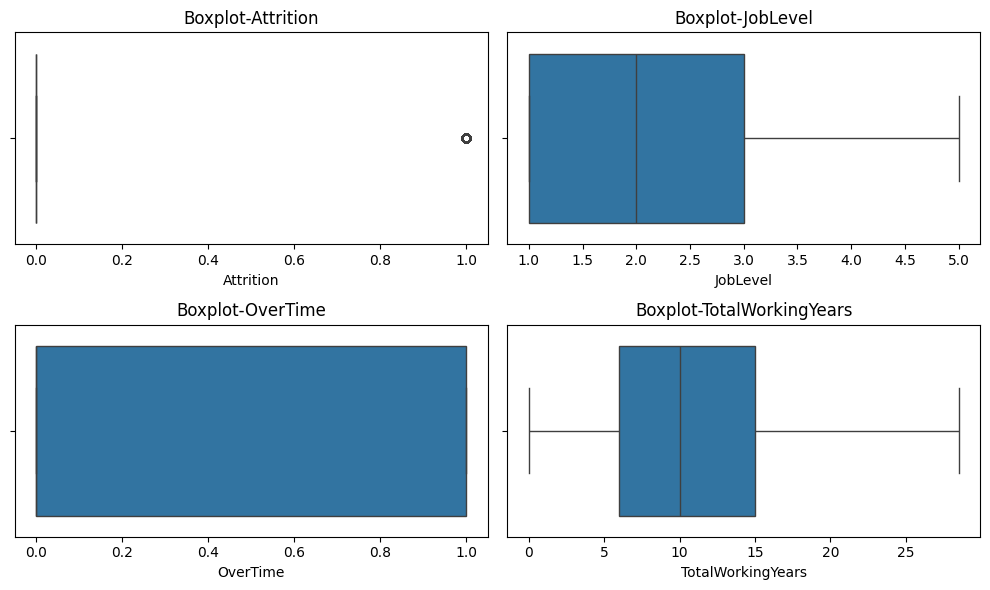

In [ ]:
import math
n_cols = 2
#Calculates the number of grid rows needed.
n_rows = math.ceil(len(df.columns) / n_cols)
plt.figure(figsize=(10, 3 * n_rows))

for i, col in enumerate(df.columns):
    plt.subplot(n_rows, n_cols, i + 1)
    # Boxplots explicitly draw outlier points beyond 1.5 * IQR
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot-{col}")

plt.tight_layout()
plt.show()

## Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X=df[["JobLevel","OverTime","TotalWorkingYears"]]
y=df["Attrition"]

In [ ]:

X.head()

,JobLevel,OverTime,TotalWorkingYears
0,2,1,8.0
1,2,0,10.0
2,1,1,7.0
3,1,1,8.0
4,1,0,6.0


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print("X_train:", X_train.shape)

X_train: (1176, 3)


## Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

In [ ]:
X_train.describe()

,JobLevel,OverTime,TotalWorkingYears
count,1176.000000,1176.000000,1176.000000
mean,2.028061,0.288265,10.934524
std,1.103215,0.453148,7.311516
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,6.000000
50%,2.000000,0.000000,10.000000
75%,3.000000,1.000000,15.000000
max,5.000000,1.000000,28.500000


In [ ]:

#Having equal row counts only confirms your dataset is complete;
#feature scaling is still necessary because individual variables operate on vastly different numerical ranges.


In [ ]:
scaler=StandardScaler()

In [ ]:
X_train_scale=scaler.fit_transform(X_train)

In [ ]:
#do not use fit transform in test data
X_test_scale=scaler.transform(X_test)

In [ ]:
# Convert back to array if needed and compute along columns (axis=0)
print("Means (should be ~0):", np.round(X_train_scale.mean(axis=0), 2))
print("Std Devs (should be 1):", np.round(X_train_scale.std(axis=0), 2))

Means (should be ~0): [ 0. -0. -0.]
Std Devs (should be 1): [1. 1. 1.]


## Class Imabalance

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
#check value count of samples
y.value_counts()

,count
Attrition,
0,1233
1,237


In [ ]:
smote=SMOTE(random_state=42)

In [ ]:
X_train_balanced,y_train_balanced=smote.fit_resample(X,y)

In [ ]:
#After Smote sampling
y_train_balanced.value_counts()

,count
Attrition,
1,1233
0,1233
